# Stage 1 Thesis Statistics Analysis

**Mục tiêu:** Phân tích 417 videos (70 categories) để chọn candidate window sizes cho Stage 2.

**Input:** `analysis/stage1/default/stage1_consolidated.parquet` (114 MB)

**Output:** 10 figures, 6 tables, candidate_window_sizes.json

## Section 0: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
sns.set_palette("colorblind")
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

# Load parquet
df = pd.read_parquet("analysis/stage1/default/stage1_consolidated.parquet")

# Type coercion (CSV string → numeric)
num_cols = ["frame_idx", "num_frames_total",
            "maskmem_max_distance", "maskmem_min_distance", "maskmem_mean_distance",
            "n_maskmem_selected", "scan_depth", "n_candidates_rejected",
            "min_iou_of_selected", "mean_iou_of_selected",
            "prev_predicted_iou", "inference_time_ms",
            "membank_ram_bytes", "process_rss_bytes", "gpu_vram_bytes"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop frame 0 sentinel (max_distance = -1, no memory bank)
df_valid = df[df["maskmem_max_distance"] >= 0].copy()

# Explode Distribution A (per-selection distance)
df_A = df_valid[["category", "video_name", "frame_idx", "maskmem_distances"]].copy()
df_A["distance"] = df_A["maskmem_distances"].apply(lambda s: json.loads(s) if s else [])
df_A = df_A.explode("distance").dropna(subset=["distance"])
df_A["distance"] = df_A["distance"].astype(int)

print(f"✓ Loaded {len(df):,} rows")
print(f"✓ Videos: {df['video_name'].nunique()}")
print(f"✓ Categories: {df['category'].nunique()}")
print(f"✓ Valid frames (after drop frame 0): {len(df_valid):,}")
print(f"✓ Distribution A (selections): {len(df_A):,}")

✓ Loaded 1,063,842 rows
✓ Videos: 415
✓ Categories: 70
✓ Valid frames (after drop frame 0): 1,063,012
✓ Distribution A (selections): 6,369,659


In [2]:
def save_fig(fig, name: str) -> None:
    """Save figure as PNG (300 DPI) + PDF (vector)"""
    Path("figures/stage1").mkdir(parents=True, exist_ok=True)
    fig.savefig(f"figures/stage1/{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(f"figures/stage1/{name}.pdf", bbox_inches="tight")
    print(f"✓ Saved figures/stage1/{name}.{{png,pdf}}")

def save_table(df_table: pd.DataFrame, name: str, caption: str = "") -> None:
    """Save table as CSV + Markdown + LaTeX"""
    Path("tables/stage1").mkdir(parents=True, exist_ok=True)
    base = f"tables/stage1/{name}"
    df_table.to_csv(f"{base}.csv", index=False)
    with open(f"{base}.md", "w") as f:
        f.write(f"**{caption}**\n\n")
        f.write(df_table.to_markdown(index=False))
    with open(f"{base}.tex", "w") as f:
        f.write(f"% {caption}\n")
        f.write(df_table.to_latex(index=False, escape=False))
    print(f"✓ Saved tables/stage1/{name}.{{csv,md,tex}}")

print("✓ Helper functions defined")

✓ Helper functions defined


In [3]:
# Sanity checks
assert df["video_name"].nunique() >= 410, "Expected ≥410 videos"
assert df["category"].nunique() == 70, "Expected 70 categories"
assert df_valid["maskmem_max_distance"].min() >= 1, "Max distance should be ≥1"
assert df_A["distance"].min() >= 1, "Selection distance should be ≥1"
print(f"✓ All sanity checks passed ({df['video_name'].nunique()} videos, {df['category'].nunique()} categories)")

✓ All sanity checks passed (415 videos, 70 categories)


## Section 1: Dataset Overview & Coverage

In [4]:
# Compute overview statistics
overview = pd.DataFrame([
    ("Videos analyzed", f"{df['video_name'].nunique()} / 420"),
    ("Categories covered", f"{df['category'].nunique()} / 70"),
    ("Total frames (incl. frame 0)", f"{len(df):,}"),
    ("Valid frames (drop frame 0)", f"{len(df_valid):,}"),
    ("Total selections (Dist A)", f"{len(df_A):,}"),
    ("Mean frames/video", f"{df.groupby('video_name').size().mean():.0f}"),
    ("Median frames/video", f"{df.groupby('video_name').size().median():.0f}"),
    ("Min frames/video", f"{df.groupby('video_name').size().min()}"),
    ("Max frames/video", f"{df.groupby('video_name').size().max()}"),
], columns=["Metric", "Value"])

print(overview.to_markdown(index=False))

| Metric                       | Value     |
|:-----------------------------|:----------|
| Videos analyzed              | 415 / 420 |
| Categories covered           | 70 / 70   |
| Total frames (incl. frame 0) | 1,063,842 |
| Valid frames (drop frame 0)  | 1,063,012 |
| Total selections (Dist A)    | 6,369,659 |
| Mean frames/video            | 2563      |
| Median frames/video          | 2160      |
| Min frames/video             | 1000      |
| Max frames/video             | 9193      |


In [5]:
save_table(overview, "01_stage1_overview",
           caption="Table 1.1: Stage 1 Dataset Overview")

✓ Saved tables/stage1/01_stage1_overview.{csv,md,tex}


In [6]:
# Compute overview statistics
overview = pd.DataFrame([
    ("Videos analyzed", f"{df['video_name'].nunique()} / 420"),
    ("Categories covered", f"{df['category'].nunique()} / 70"),
    ("Total frames (incl. frame 0)", f"{len(df):,}"),
    ("Valid frames (drop frame 0)", f"{len(df_valid):,}"),
    ("Total selections (Dist A)", f"{len(df_A):,}"),
    ("Mean frames/video", f"{df.groupby('video_name').size().mean():.0f}"),
    ("Median frames/video", f"{df.groupby('video_name').size().median():.0f}"),
    ("Min frames/video", f"{df.groupby('video_name').size().min()}"),
    ("Max frames/video", f"{df.groupby('video_name').size().max()}"),
], columns=["Metric", "Value"])

print(overview.to_markdown(index=False))

| Metric                       | Value     |
|:-----------------------------|:----------|
| Videos analyzed              | 415 / 420 |
| Categories covered           | 70 / 70   |
| Total frames (incl. frame 0) | 1,063,842 |
| Valid frames (drop frame 0)  | 1,063,012 |
| Total selections (Dist A)    | 6,369,659 |
| Mean frames/video            | 2563      |
| Median frames/video          | 2160      |
| Min frames/video             | 1000      |
| Max frames/video             | 9193      |


In [7]:
save_table(overview, "01_stage1_overview",
           caption="Table 1.1: Stage 1 Dataset Overview")

✓ Saved tables/stage1/01_stage1_overview.{csv,md,tex}


## Section 2: Distribution A & B Analysis

In [8]:
# Distribution B: per-frame max distance (primary metric)
dist_B = df_valid["maskmem_max_distance"]
dist_B_stats = pd.DataFrame([
    ("N (frames)", f"{len(dist_B):,}"),
    ("Mean", f"{dist_B.mean():.1f}"),
    ("Std", f"{dist_B.std():.1f}"),
    ("Min", f"{dist_B.min()}"),
    *[(f"P{p}", f"{int(np.percentile(dist_B, p))}")
      for p in [25, 50, 75, 90, 95, 99, 100]],
], columns=["Statistic", "Value"])

print("Distribution B (per-frame max distance) — DRIVES WINDOW SIZE SELECTION:")
print(dist_B_stats.to_markdown(index=False))
save_table(dist_B_stats, "03_distribution_B_stats",
           caption="Table 2.2: Distribution B (per-frame max distance) statistics — drives window size selection")

Distribution B (per-frame max distance) — DRIVES WINDOW SIZE SELECTION:
| Statistic   |         Value |
|:------------|--------------:|
| N (frames)  |   1.06301e+06 |
| Mean        |   9           |
| Std         |  29.4         |
| Min         |   1           |
| P25         |   6           |
| P50         |   6           |
| P75         |   6           |
| P90         |   6           |
| P95         |   8           |
| P99         |  76           |
| P100        | 913           |
✓ Saved tables/stage1/03_distribution_B_stats.{csv,md,tex}


✓ Saved figures/stage1/02_dist_B_histogram.{png,pdf}


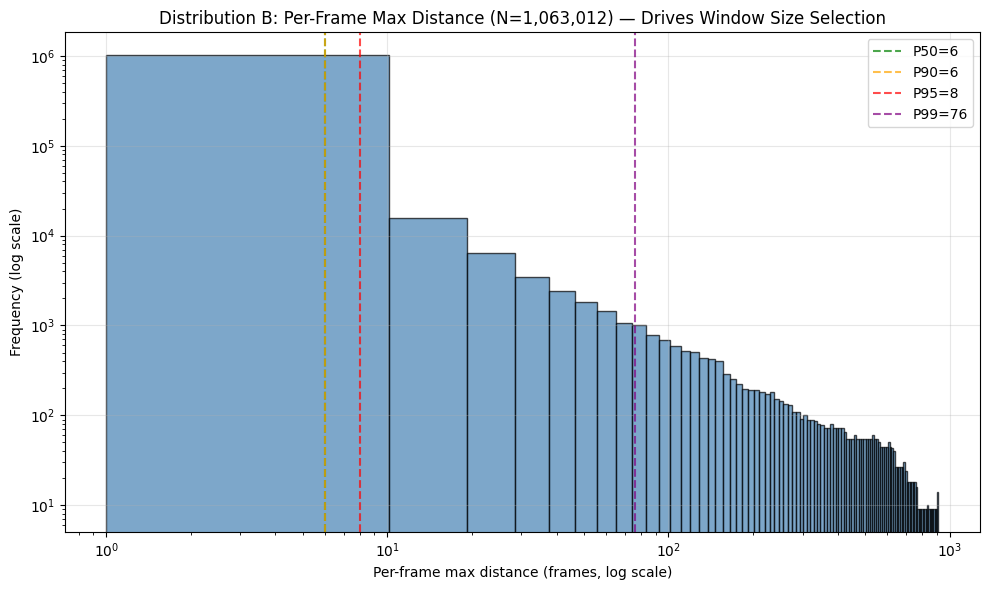

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(dist_B, bins=100, log=True, alpha=0.7, edgecolor='black', color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('Per-frame max distance (frames, log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title(f'Distribution B: Per-Frame Max Distance (N={len(dist_B):,}) — Drives Window Size Selection')

percentile_values = {p: int(np.percentile(dist_B, p)) for p in [50, 90, 95, 99]}
colors = ['green', 'orange', 'red', 'purple']
for (p, val), color in zip(percentile_values.items(), colors):
    ax.axvline(val, color=color, linestyle='--', alpha=0.7,
               label=f'P{p}={val}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "02_dist_B_histogram")
plt.show()

✓ Saved figures/stage1/03_dist_B_cdf.{png,pdf}


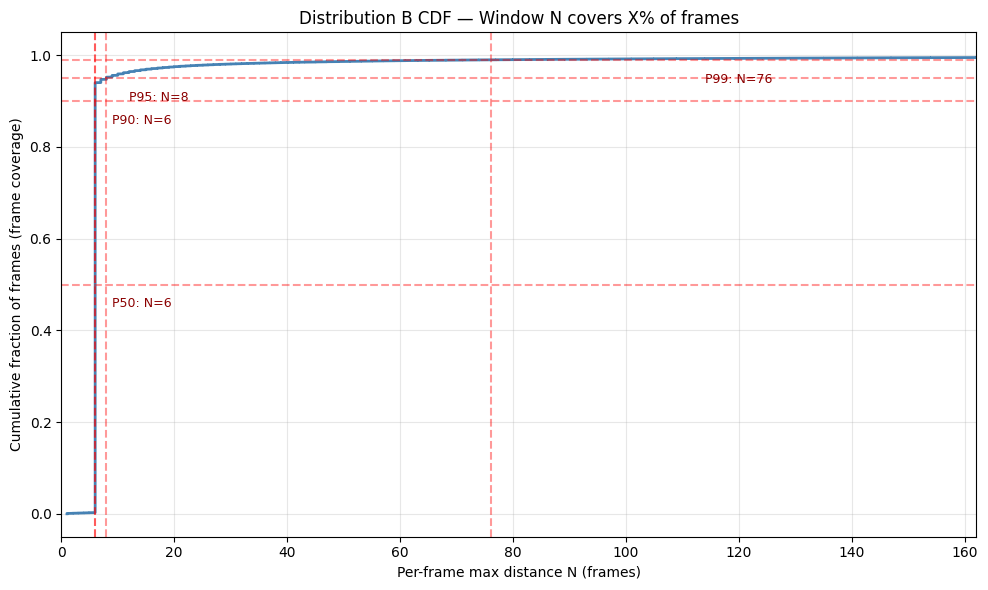

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sorted_B = np.sort(dist_B)
cdf = np.arange(1, len(sorted_B) + 1) / len(sorted_B)
ax.plot(sorted_B, cdf, linewidth=2, color='steelblue')
ax.set_xlabel('Per-frame max distance N (frames)')
ax.set_ylabel('Cumulative fraction of frames (frame coverage)')
ax.set_title('Distribution B CDF — Window N covers X% of frames')
ax.grid(True, alpha=0.3)

for p in [50, 90, 95, 99]:
    val = int(np.percentile(dist_B, p))
    ax.axvline(val, color='red', linestyle='--', alpha=0.4)
    ax.axhline(p/100, color='red', linestyle='--', alpha=0.4)
    ax.annotate(f'P{p}: N={val}', xy=(val, p/100),
                xytext=(val*1.5, p/100 - 0.05),
                fontsize=9, color='darkred')

ax.set_xlim(0, np.percentile(dist_B, 99.5))
plt.tight_layout()
save_fig(fig, "03_dist_B_cdf")
plt.show()

In [11]:
# Distribution A: per-selection temporal distance
percentiles = [25, 50, 75, 90, 95, 99, 100]
dist_A_stats = pd.DataFrame([
    ("N (total selections)", f"{len(df_A):,}"),
    ("Mean", f"{df_A['distance'].mean():.1f}"),
    ("Std", f"{df_A['distance'].std():.1f}"),
    ("Min", f"{df_A['distance'].min()}"),
    *[(f"P{p}", f"{int(np.percentile(df_A['distance'], p))}")
      for p in percentiles],
], columns=["Statistic", "Value"])

print("Distribution A (per-selection distance):")
print(dist_A_stats.to_markdown(index=False))
save_table(dist_A_stats, "02_distribution_A_stats",
           caption="Table 2.1: Distribution A (per-selection distance) statistics")

Distribution A (per-selection distance):
| Statistic            |         Value |
|:---------------------|--------------:|
| N (total selections) |   6.36966e+06 |
| Mean                 |   5.8         |
| Std                  |  26.6         |
| Min                  |   1           |
| P25                  |   2           |
| P50                  |   4           |
| P75                  |   5           |
| P90                  |   6           |
| P95                  |   6           |
| P99                  |  54           |
| P100                 | 913           |
✓ Saved tables/stage1/02_distribution_A_stats.{csv,md,tex}


✓ Saved figures/stage1/01_dist_A_histogram.{png,pdf}


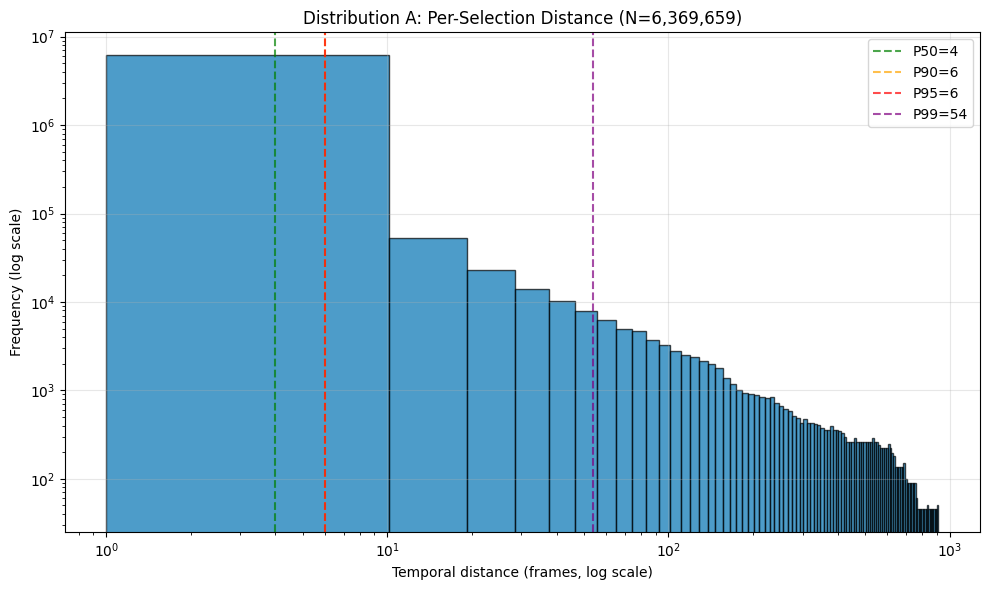

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_A["distance"], bins=100, log=True, alpha=0.7, edgecolor='black')
ax.set_xscale('log')
ax.set_xlabel('Temporal distance (frames, log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title(f'Distribution A: Per-Selection Distance (N={len(df_A):,})')

# Vertical lines at percentiles
percentile_values = {p: int(np.percentile(df_A['distance'], p))
                     for p in [50, 90, 95, 99]}
colors = ['green', 'orange', 'red', 'purple']
for (p, val), color in zip(percentile_values.items(), colors):
    ax.axvline(val, color=color, linestyle='--', alpha=0.7,
               label=f'P{p}={val}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, "01_dist_A_histogram")
plt.show()

## Section 3: Coverage Curves

## Section 4: Per-Category Analysis

## Section 5: Per-Attribute Analysis

## Section 6: Memory Bank RAM Preliminary

## Section 7: Candidate Window Sizes Selection

## Section 8: Summary Tables for Thesis